In [9]:
import pickle
with open("pre_split_data.pkl", "rb") as f:
    X, y, cat_cols, num_cols = pickle.load(f)

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# CV target encoding
def target_encode_cv(X, y, column, n_splits=5):
    """
    Cross-validated target encoding for a single feature column.
    Returns a pd.Series of encoded values (same index as X).
    """
    encoded = pd.Series(index=X.index, dtype=float)
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for train_idx, val_idx in kf.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        
        # Compute mean target per category on train fold
        means = y_train_fold.groupby(X_train_fold[column]).mean()
        
        # Map validation fold
        encoded.iloc[val_idx] = X_val_fold[column].map(means)
    
    # Fill unseen categories (rare) with global mean
    encoded.fillna(y.mean(), inplace=True)
    return encoded

# -----------------------------
# 3. Prepare XGBoost input
# -----------------------------
X_train_xgb = X_train[num_cols].copy()
X_test_xgb = X_test[num_cols].copy()

for col in cat_cols:
    if X_train[col].nunique() > 10:
        # CV target encoding for training
        X_train_xgb[col] = target_encode_cv(X_train, y_train, col)
        
        # Full-train target encoding for test set
        means = y_train.groupby(X_train[col]).mean()
        X_test_xgb[col] = X_test[col].map(means)
        # Fill unseen categories with global mean
        X_test_xgb.fillna({col:y_train.mean()}, inplace=True)
    else:
        # Frequency encoding for low-cardinality features
        freq = X_train[col].value_counts() / len(X_train)
        X_train_xgb[col] = X_train[col].map(freq)
        X_test_xgb[col] = X_test[col].map(freq).fillna(0)

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_xgb, y_train)

y_pred_xgb = xgb.predict(X_test_xgb)
y_prob_xgb = xgb.predict_proba(X_test_xgb)[:,1]


c:\Users\sarah\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [23:30:37] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [17]:

print("\n=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))
print("F1 score:", f1_score(y_test, y_pred_xgb))


=== XGBoost ===
Accuracy: 0.9573855676405411
ROC AUC: 0.9540701464560282
F1 score: 0.5914529914529915


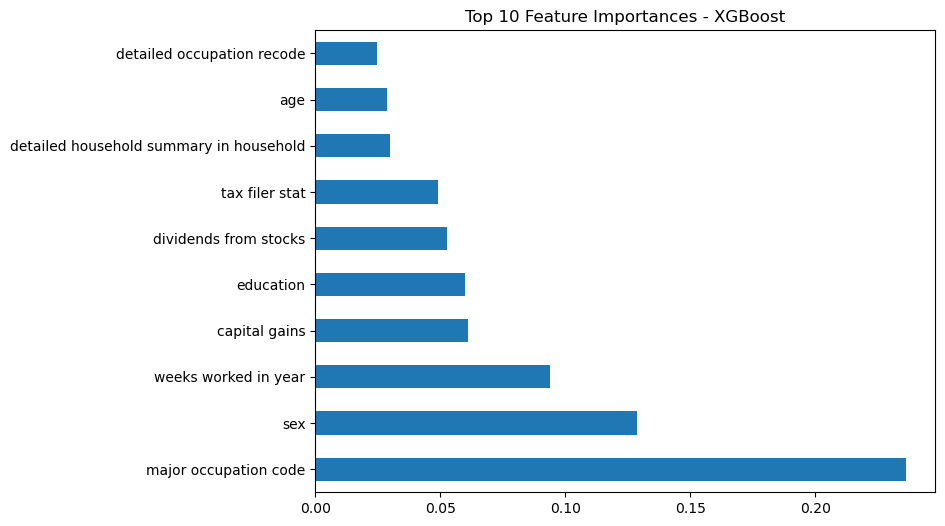

In [14]:

# ---------- 6. Feature importance ----------
import matplotlib.pyplot as plt

feat_importances = pd.Series(xgb.feature_importances_, index=X_train_xgb.columns)
feat_importances.nlargest(10).plot(kind='barh', figsize=(8,6))
plt.title("Top 10 Feature Importances - XGBoost")
plt.show()

